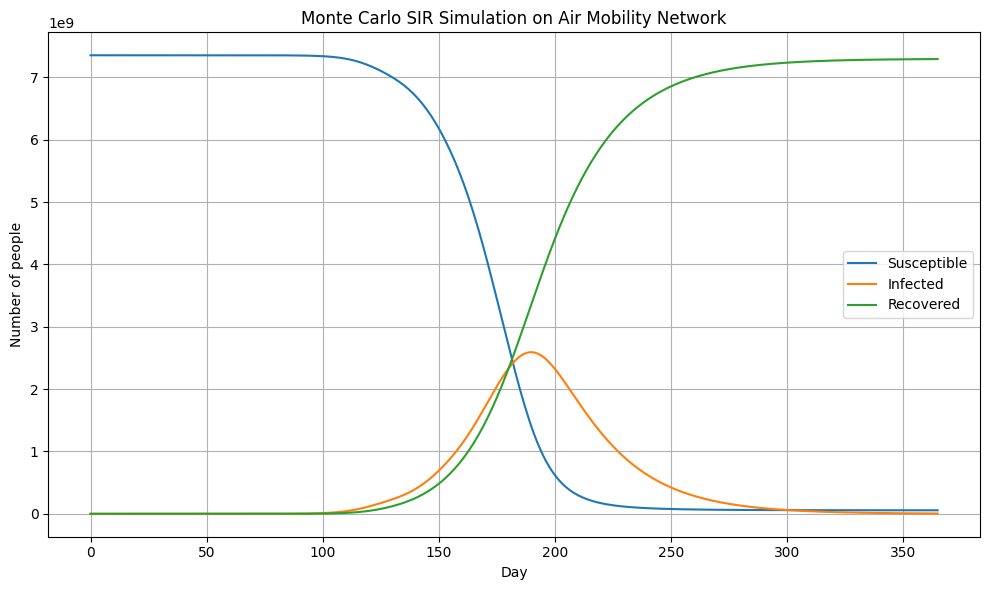

Peak day: 190
Peak infected: 2592504696


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load data
node_file = "./data/nodelist_connected.csv"
edge_file = "./data/edgelist_symmetric.csv"

nodes = pd.read_csv(node_file)
edges = pd.read_csv(edge_file)

num_nodes = len(nodes)

populations = nodes["Population"].fillna(0).astype(float).values
country_names = nodes["Label"].values


# Make directed edge list
def make_directed_edges(edges, weight_col="Avg. Number of Routes"):
    """
    Original edge file has undirected/symmetric edges.
    This function creates both directions:
        Source -> Target
        Target -> Source
    """

    forward = edges[["Source", "Target", weight_col]].copy()

    backward = edges[["Target", "Source", weight_col]].copy()
    backward.columns = ["Source", "Target", weight_col]

    directed_edges = pd.concat([forward, backward], ignore_index=True)

    return directed_edges


directed_edges = make_directed_edges(
    edges,
    weight_col="Avg. Number of Routes"
)


# Move population using daily directed flow
def move_population_by_directed_flow(
    S,
    I,
    R,
    directed_edges,
    weight_col="Avg. Number of Routes",
    passengers_per_flight=200
):
    """
    Move people using directed edge flow.

    Assumption:
    - edge weight = number of flights per day
    - one flight = passengers_per_flight people
    - daily flow = edge weight * passengers_per_flight
    """

    num_nodes = len(S)

    delta_S = np.zeros(num_nodes)
    delta_I = np.zeros(num_nodes)
    delta_R = np.zeros(num_nodes)

    for _, row in directed_edges.iterrows():
        src = int(row["Source"])
        tgt = int(row["Target"])

        daily_flow = float(row[weight_col]) * passengers_per_flight

        total_src = S[src] + I[src] + R[src]

        if total_src <= 0:
            continue

        actual_flow = min(daily_flow, total_src)

        moved_S = actual_flow * (S[src] / total_src)
        moved_I = actual_flow * (I[src] / total_src)
        moved_R = actual_flow * (R[src] / total_src)

        delta_S[src] -= moved_S
        delta_I[src] -= moved_I
        delta_R[src] -= moved_R

        delta_S[tgt] += moved_S
        delta_I[tgt] += moved_I
        delta_R[tgt] += moved_R

    new_S = S + delta_S
    new_I = I + delta_I
    new_R = R + delta_R

    return new_S, new_I, new_R


# Monte Carlo SIR simulation
def run_sir_monte_carlo(
    populations,
    directed_edges,
    initial_infected_nodes,
    initial_infected_ratio=0.001,
    beta=0.3,
    gamma=0.05,
    days=365,
    num_runs=50,
    passengers_per_flight=200,
    weight_col="Avg. Number of Routes",
    random_seed=42
):
    """
    SIR Monte Carlo simulation on a mobility network.

    S: susceptible
    I: infected
    R: recovered

    beta:
        infection strength

    gamma:
        daily recovery probability
    """

    rng = np.random.default_rng(random_seed)
    num_nodes = len(populations)

    all_S = np.zeros((num_runs, days + 1, num_nodes))
    all_I = np.zeros((num_runs, days + 1, num_nodes))
    all_R = np.zeros((num_runs, days + 1, num_nodes))

    for run in range(num_runs):

        S = populations.copy()
        I = np.zeros(num_nodes)
        R = np.zeros(num_nodes)

        # Initial infection
        for node in initial_infected_nodes:
            infected_count = max(1, int(populations[node] * initial_infected_ratio))
            infected_count = min(infected_count, S[node])

            S[node] -= infected_count
            I[node] += infected_count

        all_S[run, 0] = S
        all_I[run, 0] = I
        all_R[run, 0] = R

        for t in range(1, days + 1):

            # Mobility
            S, I, R = move_population_by_directed_flow(
                S,
                I,
                R,
                directed_edges,
                weight_col=weight_col,
                passengers_per_flight=passengers_per_flight
            )

            # Infection inside each node
            total_people = S + I + R

            for i in range(num_nodes):
                if total_people[i] <= 0:
                    continue

                infection_prob = beta * I[i] / total_people[i]
                infection_prob = min(max(infection_prob, 0), 1)

                new_infections = rng.binomial(int(S[i]), infection_prob)

                S[i] -= new_infections
                I[i] += new_infections

            # Recovery
            for i in range(num_nodes):
                recoveries = rng.binomial(int(I[i]), gamma)

                I[i] -= recoveries
                R[i] += recoveries

            all_S[run, t] = S
            all_I[run, t] = I
            all_R[run, t] = R

    return all_S, all_I, all_R


# Run simulation
initial_infected_nodes = [3]

S, I, R = run_sir_monte_carlo(
    populations=populations,
    directed_edges=directed_edges,
    initial_infected_nodes=initial_infected_nodes,
    initial_infected_ratio=0.001,
    beta=0.2,
    gamma=0.04,
    days=365,
    num_runs=50,
    passengers_per_flight=200,
    weight_col="Avg. Number of Routes",
    random_seed=42
)


# Compute average over Monte Carlo runs
mean_S = S.sum(axis=2).mean(axis=0)
mean_I = I.sum(axis=2).mean(axis=0)
mean_R = R.sum(axis=2).mean(axis=0)


# Plot SIR curves
plt.figure(figsize=(10, 6))
plt.plot(mean_S, label="Susceptible")
plt.plot(mean_I, label="Infected")
plt.plot(mean_R, label="Recovered")

plt.xlabel("Day")
plt.ylabel("Number of people")
plt.title("Monte Carlo SIR Simulation on Air Mobility Network")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Print peak infection information
peak_day = np.argmax(mean_I)
peak_infected = mean_I[peak_day]

print("Peak day:", peak_day)
print("Peak infected:", int(peak_infected))